In [7]:
#@title Importations

import random
import timeit
import matplotlib.pyplot as plt

In [3]:
#@title Fonctions

def liste_elements_pairs(nb_elements):
    """
        Retourne une liste de nb_elements pairs. Pour tester des fonctions de
        recherche.
    """
    return [x for x in range(0, nb_elements*2, 2)]

def liste_inverse(nb_valeurs=10000):
    liste = [0]
    for i in range(1, nb_valeurs):
        liste.insert(0, i)
    return liste


In [ ]:
#@title Exercice 2.1

def recherche_lineaire_triee(elements, cible):

    for element in elements:
        if element == cible:
            return True
        elif cible < element:
            return False
    return False

elements = liste_elements_pairs(10)

print(recherche_lineaire_triee(elements, 5))
print(recherche_lineaire_triee(elements, 18))
print(recherche_lineaire_triee(elements, 20))


False
True
False


In [ ]:
#@title Exercice 2.2

def recherche_dichotomique(elements, cible):

    trouve = False
    gauche = 0
    droite = len(elements) - 1
    while gauche <= droite and not trouve:
        milieu = (gauche + droite) // 2
        if elements[milieu] == cible:
            trouve = True
        elif cible < elements[milieu]:
            droite = milieu - 1
        else:
            gauche = milieu + 1
    return trouve

elements = liste_elements_pairs(10)

print(recherche_dichotomique(elements, 5))
print(recherche_dichotomique(elements, 18))
print(recherche_dichotomique(elements, 20))


False
True
False


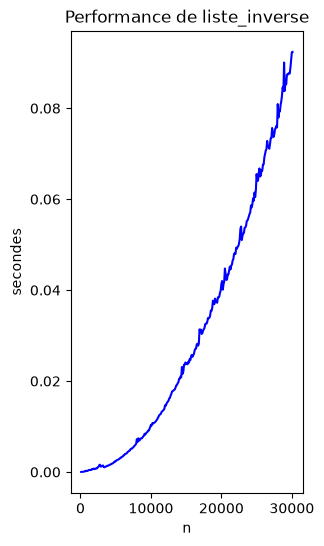

In [6]:
#@title Exercice 2.3

temps = []
quantite_donnees = [100]

for i in range(300):
    quantite_donnees.append(quantite_donnees[-1] + 100)

for n in quantite_donnees:
    temps_execution = timeit.repeat(lambda: liste_inverse(n), number=1, repeat=3)
    temps.append(sum(temps_execution) / len(temps_execution))

plt.figure(figsize=(3,6))
plt.title("Performance de liste_inverse")
plt.xlabel("n")
plt.ylabel("secondes", rotation=90)
plt.plot(quantite_donnees, temps, "-b")
plt.show()

In [ ]:
#@title Exercice 2.4

def liste_inverse_amelioree(n):
    valeurs = list(range(n-1, -1, -1))
    return valeurs

temps = []
quantite_donnees = [100]
nb_executions = 500

for i in range(300):
    quantite_donnees.append(quantite_donnees[-1] + 100)

for n in quantite_donnees:
    temps_execution = timeit.timeit(lambda: liste_inverse_amelioree(n), number=nb_executions)
    temps.append(temps_execution / nb_executions)

plt.figure(figsize=(3,6))
plt.title("Performance de liste_inverse_amelioree")
plt.xlabel("n")
plt.ylabel("secondes", rotation=90)
plt.plot(quantite_donnees, temps, "-b")
plt.show()


In [ ]:
#@title Exercice 2.5

NOMBRE_RECHERCHES = 200

def selectionner_elements(elements, nb_elements):
    """
        Fonction qui sélectionne un certain nombre d'éléments dans la liste d'éléments.
        Ils seront ensuite utilisés pour faire un certain nombre de recherches.
    """
    elements_selectionnes = []
    for i in range(nb_elements):
        pourcentage = random.randint(1, 100)
        if pourcentage <= 80:
            # Élément dans la liste
            indice_aleatoire = random.randint(0, len(elements)-1)
            elements_selectionnes.append(elements[indice_aleatoire])
        elif pourcentage <= 85:
            # Valeur plus petite
            elements_selectionnes.append(elements[0] - 1)
        elif pourcentage <= 90:
            # Valeur plus grande
            elements_selectionnes.append(elements[-1] + 1)
        else:
            # Valeur impaire dans les bornes de la liste
            indice_aleatoire = random.randint(1, len(elements)-1)
            elements_selectionnes.append(elements[indice_aleatoire]-1)

    return elements_selectionnes

def faire_recherches_lineaires(liste_elements, elements_recherches):
    for element in elements_recherches:
        recherche_lineaire_triee(liste_elements, element)

def faire_recherches_dichotomiques(liste_elements, elements_recherches):
    for element in elements_recherches:
        recherche_dichotomique(liste_elements, element)

# Début de la prise de temps
temps_lineaire = []
temps_dichotomique = []
quantite_donnees = [100]

for i in range(300):
    quantite_donnees.append(quantite_donnees[-1] + 100)

for n in quantite_donnees:
    liste_elements = liste_elements_pairs(n)
    elements_cherches = selectionner_elements(liste_elements, NOMBRE_RECHERCHES)
    resultat_lineaire = timeit.repeat(lambda: faire_recherches_lineaires(liste_elements, elements_cherches), number=1, repeat=3)
    temps_lineaire.append(sum(resultat_lineaire) / len(resultat_lineaire))

    resultat_dichotomique = timeit.timeit(lambda: faire_recherches_dichotomiques(liste_elements, elements_cherches), number=100)
    temps_dichotomique.append(resultat_dichotomique/100)

# Production des deux graphiques
plt.figure(figsize=(6,6))
plt.title("Performance de la recherche linéaire")
plt.xlabel("n")
plt.ylabel("secondes", rotation=90)
plt.plot(quantite_donnees, temps_lineaire, "-b")
plt.show()

plt.figure(figsize=(6,6))
plt.title("Performance de la recherche dichotomique")
plt.xlabel("n")
plt.ylabel("secondes", rotation=90)
plt.plot(quantite_donnees, temps_dichotomique, "-b")
plt.show()


In [ ]:
#@title Exercice 2.6

# Fonctions à évaluer

def additionner_plus_grands_v1(liste):
    copie = sorted(liste)
    return copie[-3] + copie[-2] + copie[-1]

def additionner_plus_grands_v2(liste):
    copie = liste.copy()
    somme = 0
    for i in range(3):
        valeur_maximale = max(copie)
        somme += valeur_maximale
        indice = copie.index(valeur_maximale)
        copie.pop(indice)

    return somme

def additionner_plus_grands_v3(liste):
    somme = 0
    indice_exclus = []
    for compteur in range(3):
        valeur_max = min(liste) - 1
        indice_candidat = 0
        for i in range(len(liste)):
            if liste[i] > valeur_max and i not in indice_exclus:
                indice_candidat = i
                valeur_max = liste[i]
        somme += valeur_max
        indice_exclus.append(indice_candidat)

    return somme


def generer_valeur_aleatoire(nombre_valeurs):
    valeurs = []
    for i in range(nombre_valeurs):
        valeur = random.randint(1, 1000000)
        valeurs.append(valeur)
    return valeurs

# Commencement des tests
y_v1 = []
y_v2 = []
y_v3 = []
quantite_donnees = [100]

for i in range(200):
    quantite_donnees.append(quantite_donnees[-1] + 1000)

for n in quantite_donnees:
    valeurs = generer_valeur_aleatoire(n)

    liste_temps_v1 = timeit.repeat(lambda: additionner_plus_grands_v1(valeurs), number=1, repeat=5)
    y_v1.append(sum(liste_temps_v1) / len(liste_temps_v1))

    liste_temps_v2 = timeit.repeat(lambda: additionner_plus_grands_v2(valeurs), number=1, repeat=5)
    y_v2.append(sum(liste_temps_v2) / len(liste_temps_v2))

    liste_temps_v3 = timeit.repeat(lambda: additionner_plus_grands_v3(valeurs), number=1, repeat=5)
    y_v3.append(sum(liste_temps_v3) / len(liste_temps_v3))

# On fait les graphiques
plt.figure(figsize=(6,6))
plt.title("Comparaison des algorithmes")
plt.xlabel("n")
plt.ylabel("secondes", rotation=90)
plt.plot(quantite_donnees, y_v1, "-b", label="version 1")
plt.plot(quantite_donnees, y_v2, "-r", label="version 2")
plt.plot(quantite_donnees, y_v3, "-g", label="version 3")
plt.legend()
plt.show()


In [ ]:
#@title Exercice 2.7

def enlever_doublons(elements):
    i = 0
    liste_sans_doublons = []
    for element in elements:
        if element not in liste_sans_doublons:
            liste_sans_doublons.append(element)
    return liste_sans_doublons

liste = [2, 4, 5, 4, 2, 8, 7, 6, 5, 9, 8]
print(enlever_doublons(liste))

def trouver_mediane(elements):
    """
        Trouve la médiane dans une liste d'entiers triés.
    """
    milieu = len(elements) // 2
    if len(elements) % 2 == 0:
        return (elements[milieu - 1] + elements[milieu]) / 2
    else:
        return elements[milieu]

liste_triee_1 = [2, 4, 5, 7, 9]
print(trouver_mediane(liste_triee_1))

liste_triee_2 = [2, 4, 5, 7, 9, 10]
print(trouver_mediane(liste_triee_2))

def somme_valeurs_pairs(liste):
    somme = 0
    for valeur in liste:
        if valeur % 2 == 0:
            somme += valeur
    return somme

liste = [2, 3, 4, 5, 6, 8, 2]
print(somme_valeurs_pairs(liste))


def est_bissextile(annee):
    return annee % 400 == 0 or (annee % 4 == 0 and annee % 100 != 0)

print(est_bissextile(2000))
print(est_bissextile(2004))
print(est_bissextile(1900))
print(est_bissextile(2025))